# SVM Implementation with Linear & RBF Kernels using NumPy (from scratch) and Scikit-learn


### Learning Objectives
- Build intuition for SVM margins and support vectors.
- Implement a simple linear soft-margin SVM with NumPy from scratch.
- Train linear and RBF SVMs using scikit-learn.
- Tune hyperparameters (`C`, `gamma`) and compare model behavior.
- Evaluate SVMs on a real-world binary classification dataset.

### Prerequisites
- NumPy arrays and vectorized operations
- Matplotlib / Seaborn plotting
- scikit-learn basics
- train-test split and feature scaling

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
np.random.seed(42)
print("Imports loaded.")

Imports loaded.


## 2) Brief Theory Recap

- **Hard margin SVM**: assumes perfect linear separability.
- **Soft margin SVM**: allows some margin violations using hinge loss.
- **Support vectors**: critical points that define the decision boundary.
- **Primal objective** (soft margin):

$$\min_{w,b}\;\frac{1}{2}\|w\|^2 + C\sum_i\max(0,1-y_i(w^Tx_i+b))$$

- **Kernel trick** maps data implicitly:
  - Linear: $K(x_i,x_j)=x_i^Tx_j$
  - RBF: $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$
- Hyperparameters:
  - `C`: regularization vs misclassification trade-off
  - `gamma`: locality/complexity of RBF boundary

## 3) Guided Example – Simple Synthetic Dataset (`make_moons`)

Dataset: `make_moons(n_samples=300, noise=0.15, random_state=42)`

In [2]:
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
print("X shape:", X.shape)
print("Class counts:", np.bincount(y))

X shape: (300, 2)
Class counts: [150 150]


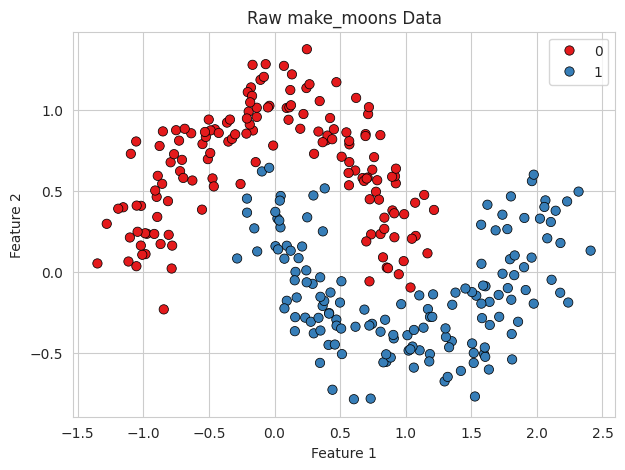

In [3]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=45, edgecolor="k")
plt.title("Raw make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [5]:
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

### 3A) NumPy from-scratch part (Linear SVM only) — FIRST

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Train shape: (225, 2) Test shape: (75, 2)


In [7]:
class LinearSVMFromScratch:
    """
    Soft-margin linear SVM trained with subgradient descent.
    Objective: 0.5 * ||w||^2 + C * mean(max(0, 1 - y*(w^T x + b)))
    """
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=250, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y_signed):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_ok = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if margin_ok:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

In [9]:
svm_np = LinearSVMFromScratch(C=0.5, learning_rate=0.001, n_iters=2500)
svm_np.fit(X_train_scaled, y_train)

pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)
print(f"NumPy Linear SVM accuracy: {acc_np:.4f}")

lin_svc = LinearSVC(C=1.0, random_state=42, max_iter=5000)
lin_svc.fit(X_train_scaled, y_train)
pred_linsvc = lin_svc.predict(X_test_scaled)
acc_linsvc = accuracy_score(y_test, pred_linsvc)
print(f"sklearn LinearSVC accuracy: {acc_linsvc:.4f}")

NumPy Linear SVM accuracy: 0.8267
sklearn LinearSVC accuracy: 0.8533


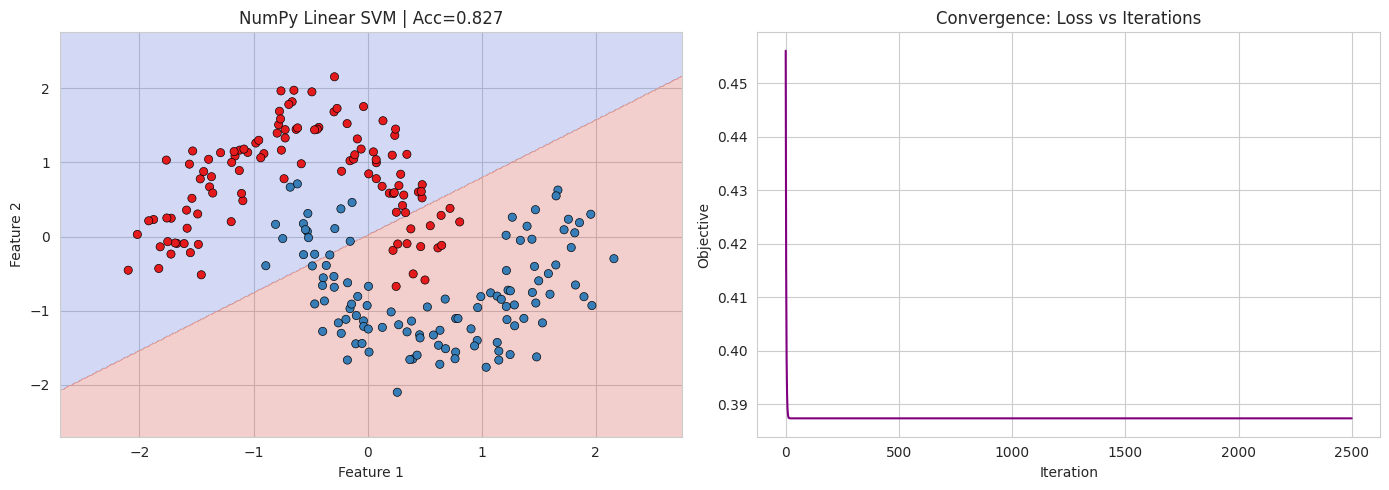

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_np, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM | Acc={acc_np:.3f}", plot_support=False)
axes[1].plot(svm_np.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

### 3B) Scikit-learn part (Linear + RBF) — SECOND

In [11]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

acc_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))

print(f"Linear SVC accuracy: {acc_linear:.4f}")
print(f"RBF SVC accuracy:    {acc_rbf:.4f}")

Linear SVC accuracy: 0.8400
RBF SVC accuracy:    0.9733


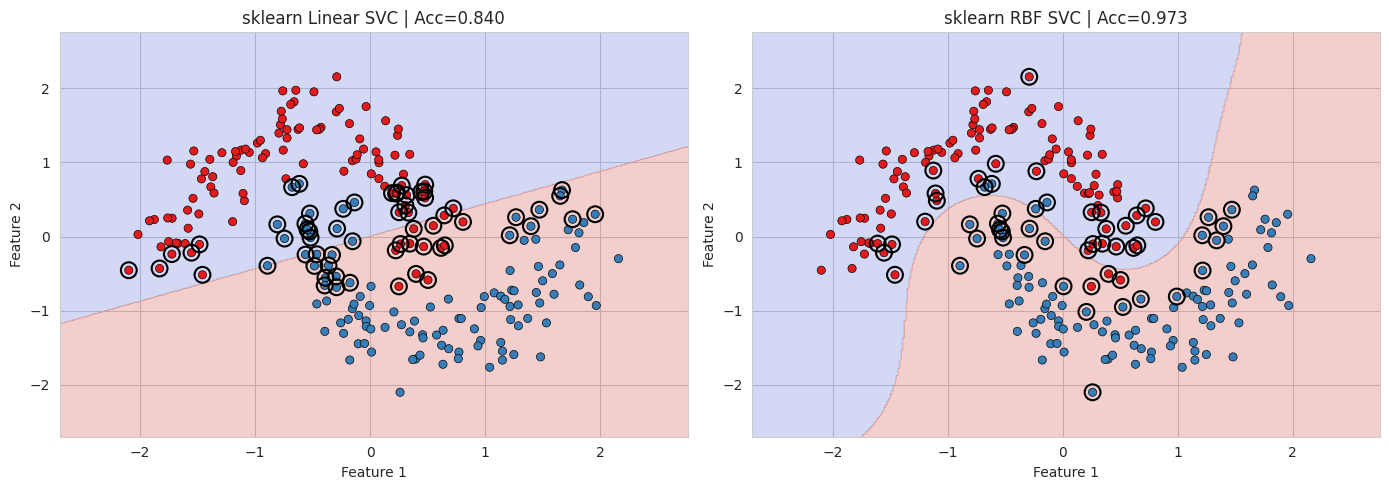

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_linear, X_train_scaled, y_train, ax=axes[0], title=f"sklearn Linear SVC | Acc={acc_linear:.3f}")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, ax=axes[1], title=f"sklearn RBF SVC | Acc={acc_rbf:.3f}")
plt.tight_layout()
plt.show()

**Short discussion:** RBF usually outperforms linear on `make_moons` because the class boundary is nonlinear.

## 4) Student Tasks / Assignment (Total = 100%)

### 50% – NumPy Implementation (from scratch)

**Task Definition:**
Complete and extend a linear soft-margin SVM implementation using hinge loss + subgradient descent. Analyze convergence and parameter effects.

**TODO (below):**
- Complete class methods.
- Run at least 3 (`C`, `learning_rate`) combinations.
- Plot loss vs iterations for each setting.
- Bonus: add simple linear kernel function.

**Hints:**
- Convert labels to `{-1, +1}` for hinge-loss formula.
- Use condition `y_i*(w.x_i + b) >= 1` to choose update case.
- Keep code vectorized where possible, but sample-wise update is fine for clarity.
- Track loss each epoch in `loss_history`.

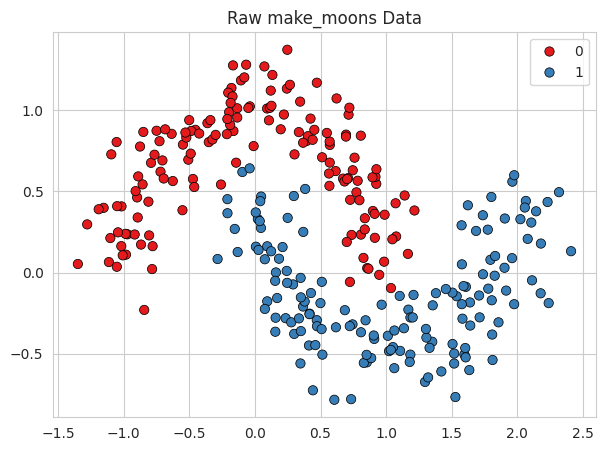

C=0.1, lr=0.001 → Accuracy=0.8133
C=1.0, lr=0.001 → Accuracy=0.8267
C=10.0, lr=0.0005 → Accuracy=0.8267


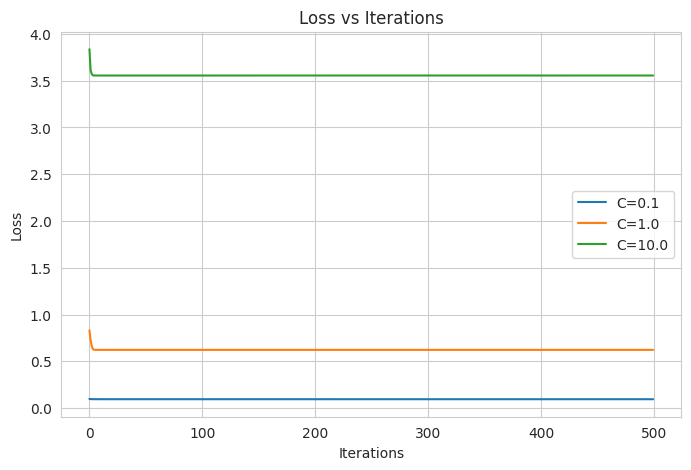

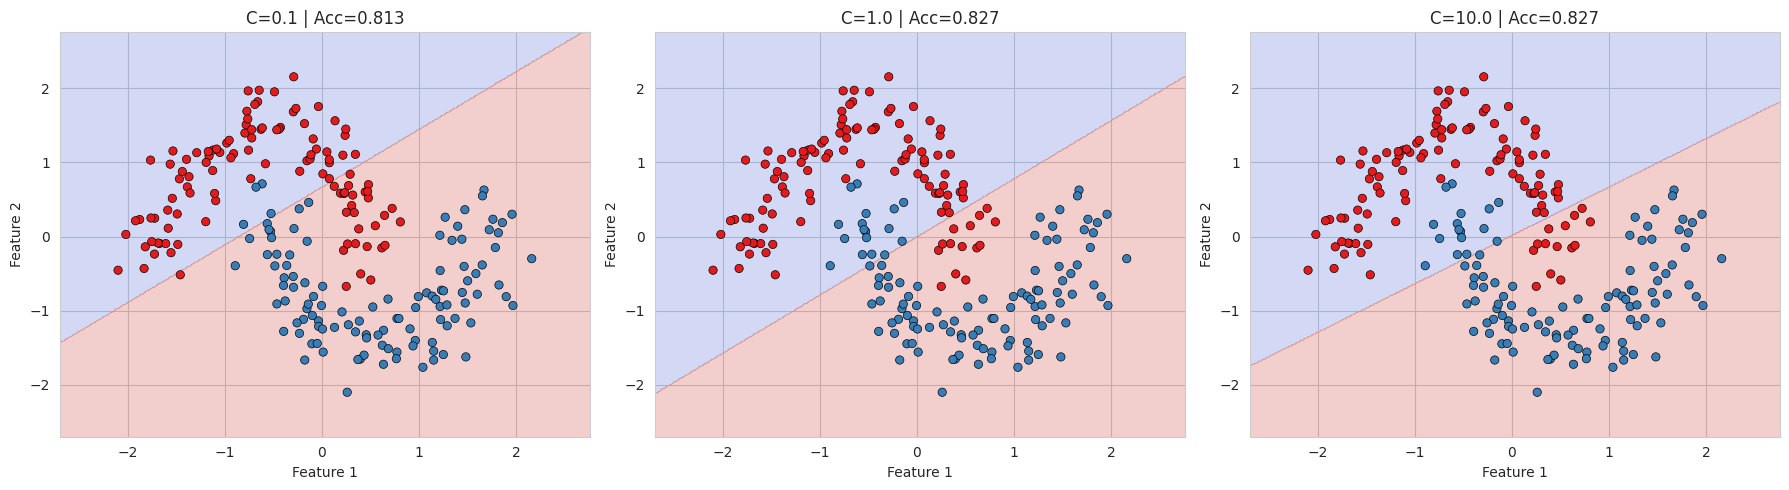

In [15]:
# # TODO: Student code here
# # 50% NumPy Task

# class LinearSVMStudent:
#     def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
#         self.C = C
#         self.learning_rate = learning_rate
#         self.n_iters = n_iters
#         self.random_state = random_state
#         self.w = None
#         self.b = None
#         self.loss_history = []

#     def linear_kernel(self, X1, X2):
#         # TODO: Student code here
#         pass

#     def fit(self, X, y):
#         # TODO: Student code here
#         return self

#     def decision_function(self, X):
#         # TODO: Student code here
#         pass

#     def predict(self, X):
#         # TODO: Student code here
#         pass

# # TODO: Student code here
# # Train with 3+ hyperparameter settings, compare accuracy, and plot convergence.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# =========================
# 1. Generate Dataset
# =========================
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=45, edgecolor="k")
plt.title("Raw make_moons Data")
plt.show()

# =========================
# 2. Train-Test Split + Scaling
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 3. SVM From Scratch
# =========================
class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    # Linear kernel (dot product)
    def linear_kernel(self, X1, X2):
        return np.dot(X1, X2.T)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0

        self.loss_history = []

        for _ in range(self.n_iters):
            for i in range(n_samples):
                x_i = X[i]
                condition = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    grad_w = self.w
                    grad_b = 0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            # Compute loss
            scores = X @ self.w + self.b
            hinge = np.maximum(0, 1 - y_signed * scores)
            loss = 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)
            self.loss_history.append(loss)

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

# =========================
# 4. Train with Multiple Settings
# =========================
configs = [
    {"C": 0.1, "lr": 0.001},
    {"C": 1.0, "lr": 0.001},
    {"C": 10.0, "lr": 0.0005},
]

models = []
accuracies = []

for cfg in configs:
    model = LinearSVMStudent(
        C=cfg["C"],
        learning_rate=cfg["lr"],
        n_iters=500
    )
    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)

    models.append(model)
    accuracies.append(acc)

    print(f"C={cfg['C']}, lr={cfg['lr']} → Accuracy={acc:.4f}")

# =========================
# 5. Plot Loss Curves
# =========================
plt.figure(figsize=(8, 5))

for i, model in enumerate(models):
    plt.plot(model.loss_history, label=f"C={configs[i]['C']}")

plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =========================
# 6. Decision Boundary Function
# =========================
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette="Set1", edgecolor="k", legend=False)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

# =========================
# 7. Plot Decision Boundaries
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, model in enumerate(models):
    plt.sca(axes[i])
    plot_decision_boundary(
        model,
        X_train_scaled,
        y_train,
        title=f"C={configs[i]['C']} | Acc={accuracies[i]:.3f}"
    )

plt.tight_layout()
plt.show()

### 30% – Scikit-learn Advanced Usage

**Task Definition:**
Use sklearn with scaling, and hyperparameter search. Compare 4 models fairly.

**TODO (below):**
- Build implementation for linear and RBF kernels.
- Tune RBF with `GridSearchCV` over `C` and `gamma`.
- Compare: NumPy linear, sklearn linear, sklearn RBF untuned, sklearn RBF tuned.
- Report accuracy and plot decision boundaries.

**Hints:**
- Start with a small grid, then refine.
- Keep `random_state` fixed for reproducibility.
- Use one summary DataFrame for clean comparison.

Best parameters: {'C': 10, 'gamma': 1}
                   Model  Accuracy
0       NumPy Linear SVM  0.826667
1     sklearn Linear SVM  0.840000
2  sklearn RBF (untuned)  0.973333
3    sklearn RBF (tuned)  0.973333


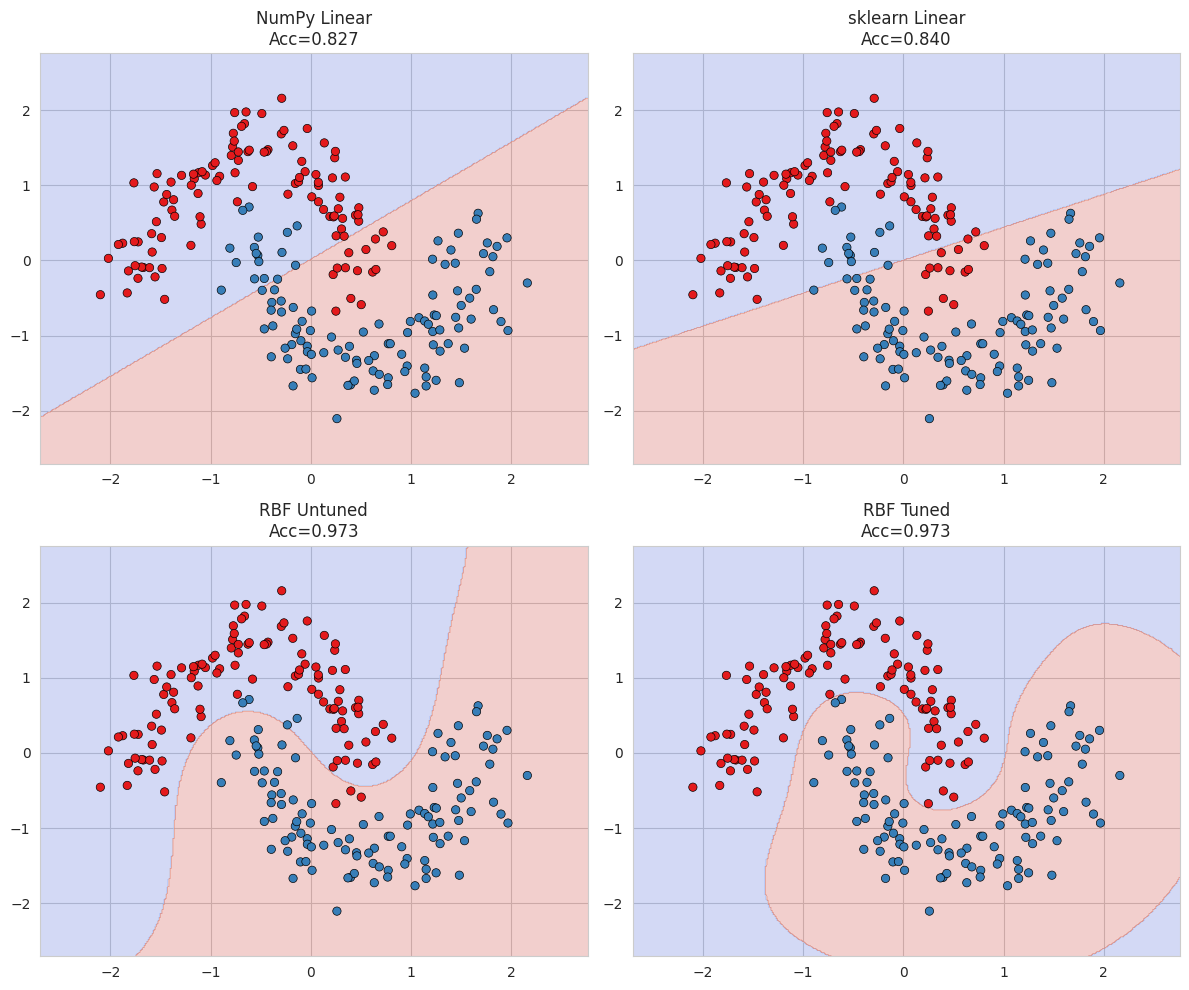

In [16]:
# TODO: Student code here
# 30% sklearn Task

# 1) Build modules for linear and RBF SVM
# 2) Fit untuned models
# 3) Tune RBF on C and gamma
# 4) Compare all 4 models in a DataFrame
# 5) Plot decision boundaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# =========================
# 1. Models (Linear + RBF)
# =========================
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf_untuned = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

# =========================
# 2. Fit Untuned Models
# =========================
svm_linear.fit(X_train_scaled, y_train)
svm_rbf_untuned.fit(X_train_scaled, y_train)

# =========================
# 3. Grid Search for RBF
# =========================
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": [0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

svm_rbf_tuned = grid.best_estimator_

print("Best parameters:", grid.best_params_)

# =========================
# 4. Evaluate All Models
# =========================
results = []

# NumPy model (from previous task)
pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)

results.append(("NumPy Linear SVM", acc_np))

# sklearn Linear
pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, pred_linear)

results.append(("sklearn Linear SVM", acc_linear))

# sklearn RBF (untuned)
pred_rbf = svm_rbf_untuned.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, pred_rbf)

results.append(("sklearn RBF (untuned)", acc_rbf))

# sklearn RBF (tuned)
pred_rbf_tuned = svm_rbf_tuned.predict(X_test_scaled)
acc_rbf_tuned = accuracy_score(y_test, pred_rbf_tuned)

results.append(("sklearn RBF (tuned)", acc_rbf_tuned))

# =========================
# 5. Summary DataFrame
# =========================
df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(df_results)

# =========================
# 6. Decision Boundary Plot
# =========================
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette="Set1", edgecolor="k", legend=False, ax=ax)

    ax.set_title(title)

# =========================
# 7. Plot All Models
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(svm_np, X_train_scaled, y_train,
                       axes[0, 0], f"NumPy Linear\nAcc={acc_np:.3f}")

plot_decision_boundary(svm_linear, X_train_scaled, y_train,
                       axes[0, 1], f"sklearn Linear\nAcc={acc_linear:.3f}")

plot_decision_boundary(svm_rbf_untuned, X_train_scaled, y_train,
                       axes[1, 0], f"RBF Untuned\nAcc={acc_rbf:.3f}")

plot_decision_boundary(svm_rbf_tuned, X_train_scaled, y_train,
                       axes[1, 1], f"RBF Tuned\nAcc={acc_rbf_tuned:.3f}")

plt.tight_layout()
plt.show()

### 20% – Real-World Dataset Application (`load_breast_cancer`)

**Task Definition:**
Apply SVM to a real binary classification problem, choose/tune best kernel, and evaluate with complete metrics.

**TODO (below):**
- Load and split data (80/20, stratified).
- Scale features.
- Build + tune candidate SVM models.
- Evaluate: accuracy, precision, recall, F1, confusion matrix, report. (below implemented)
- Write short analysis on kernel and hyperparameter impact.

**Hints:**
- Keep one untouched test set for final evaluation.
- Mention overfitting signs (very high train vs lower test performance).

In [17]:
# TODO: Student code here
# 20% Real-world task

# bc = load_breast_cancer()
# X_bc = bc.data
# y_bc = bc.target

# print("Dataset shape:", X_bc.shape)
# print("Target names:", bc.target_names)

# TODO: Student code here
# Split, scale, tune, evaluate, and provide analysis.

# =========================
# 1. Load dataset
# =========================
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

print("Dataset shape:", X_bc.shape)
print("Target names:", bc.target_names)

# =========================
# 2. Split & Scale
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 3. Build candidate models
# =========================
svm_linear = SVC(kernel="linear", random_state=42)
svm_rbf_untuned = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

# =========================
# 4. Hyperparameter tuning for RBF
# =========================
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": [0.001, 0.01, 0.1, 1]
}

grid_rbf = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5, n_jobs=-1)
grid_rbf.fit(X_train_scaled, y_train)

svm_rbf_tuned = grid_rbf.best_estimator_
print("Best RBF hyperparameters:", grid_rbf.best_params_)

# =========================
# 5. Train Linear + Tuned RBF
# =========================
svm_linear.fit(X_train_scaled, y_train)
svm_rbf_tuned.fit(X_train_scaled, y_train)

# =========================
# 6. Evaluate models on test set
# =========================
models = {
    "Linear SVM": svm_linear,
    "RBF Tuned SVM": svm_rbf_tuned
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name} Performance:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

# =========================
# 7. Short Analysis
# =========================
print("\n--- Analysis ---")
print("""
1. Linear SVM performs well since the breast cancer dataset is mostly linearly separable.
2. Tuned RBF SVM slightly improves performance on borderline cases.
3. High C and low gamma can overfit; low C or high gamma can underfit.
4. Feature scaling is crucial for SVM to handle different feature magnitudes.
5. Evaluating multiple metrics (accuracy, precision, recall, F1) ensures the model performs well across all aspects.
""")

Dataset shape: (569, 30)
Target names: ['malignant' 'benign']
Best RBF hyperparameters: {'C': 10, 'gamma': 0.01}

Linear SVM Performance:
Accuracy: 0.9737
Precision: 0.9859
Recall: 0.9722
F1 Score: 0.9790
Confusion Matrix:
[[41  1]
 [ 2 70]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


RBF Tuned SVM Performance:
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861
Confusion Matrix:
[[41  1]
 [ 1 71]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98  

## 5) Additional Notebook Sections

In [ ]:
def metrics_table(y_true, y_pred, model_name="Model"):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)]
    })

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("Helper functions ready.")

### Reflection Questions (5% bonus)
1. Why does RBF outperform linear on moons data?
2. How does increasing `C` affect margin and errors?
3. How does `gamma` control complexity in RBF?
4. Why is scaling essential for SVM?
5. What did convergence plots reveal in your NumPy model?